
# Calibrating Spectroscopy and Photometry for Consistent Flux Scaling

**Author:** Alexa Morales  
**Affiliation:** Department of Astronomy, University of Texas at Austin  

---

## Overview

This tutorial demonstrates a professional, reproducible workflow for cross-calibrating spectroscopic and photometric observations of galaxies. Such calibration is essential when combining datasets from instruments like **JWST/NIRSpec** and **JWST/NIRCam**, where slit losses, extraction effects, and independent flux calibration pipelines can introduce systematic offsets.

The notebook is structured to reflect best practices in astronomical data analysis:

- Clear separation of data ingestion, validation, and modeling
- Signal-to-noise filtering for robust calibration
- Synthetic photometry derived from spectra
- Polynomial-based correction modeling
- Transparent diagnostics and visualization



## Scientific Motivation

Spectroscopic and photometric observations probe complementary aspects of galaxy physics. However, differences in aperture losses, PSF matching, and extraction methods frequently lead to inconsistencies in absolute flux scaling.

To enable accurate measurements of derived quantities (e.g., UV slopes, emission-line equivalent widths), we must:

1. Generate synthetic photometry from the spectrum.
2. Compare synthetic and observed photometric fluxes.
3. Fit a smooth correction function when sufficient S/N data are available.
4. Apply the correction to the full spectrum.

When fewer than two photometric points meet the S/N threshold, no correction is applied and the original spectrum is retained. This conditional logic prevents overfitting and preserves physical reliability.



## Data Requirements and Assumptions

This tutorial assumes:

- A 1D extracted spectrum with wavelength and flux density.
- A catalog of broadband photometry with fluxes and uncertainties.
- Filter transmission curves for synthetic photometry calculation.
- A spectroscopic redshift (if rest-frame quantities are needed).

Flux densities may be expressed in either **Fν (Jy)** or **Fλ (erg s⁻¹ cm⁻² Å⁻¹)**. Care is taken to maintain unit consistency throughout.

All computations are performed using open-source Python tools commonly adopted within STScI-supported workflows, including:

- `numpy`
- `astropy`
- `matplotlib`



## Signal-to-Noise Selection Criteria

Before performing any calibration fit, we enforce a minimum signal-to-noise ratio (S/N > 2 by default). This ensures that:

- Poorly constrained photometric measurements do not bias the correction curve.
- The Chebyshev polynomial fit remains stable.
- The resulting correction reflects real systematic trends rather than noise fluctuations.

If fewer than two filters satisfy the S/N requirement, the correction step is skipped.




## Polynomial-Based Spectral Correction

We model the ratio:

    R(λ) = F_photometric / F_synthetic

as a smooth function of wavelength using a Chebyshev polynomial.

Why Chebyshev polynomials?

- Numerically stable over bounded intervals.
- Minimizes oscillatory artifacts compared to high-order standard polynomials.

The fitted function is evaluated across the full spectral wavelength grid and applied multiplicatively to produce the corrected spectrum.



## Diagnostic Visualization

Professional data products require transparent diagnostics. In this notebook, we will utilize and generate:

- Observed photometric fluxes with uncertainties
- Synthetic photometry derived from the spectrum
- The fitted correction curve (if applied)
- The corrected spectrum overlayed on the original

Clear labeling, unit specification, and legend annotation ensure reproducibility and publication readiness.



## Summary

In this tutorial, we:

- Computed synthetic photometry from a spectrum
- Applied S/N-based quality filtering
- Fit a smooth correction curve using Chebyshev polynomials
- Applied the correction conditionally
- Generated diagnostic-quality plots



# Calibrating JWST NIRSpec PRISM Spectra and NIRCam Photometry: Scaling to a Common Flux Level

In multi-wavelength astronomy, spectroscopic and photometric datasets often require cross-calibration. In this tutorial, we:

1. Load spectroscopic and photometric data **(Inaccessible and strictly an example for job application)**
2. Compute synthetic photometry from NIRSpec PRISM data
3. Derive a scaling factor
4. Apply the correction curve to the spectra
5. Validate agreement between spectra and photometry


## 1. Import Required Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d # Used to interpolate the photometry and spectra
from numpy.polynomial.chebyshev import Chebyshev # This is the polynomial function we will be utilizing for the correction curve
import astropy
import astropy.units as u
import astropy.constants as const
from astropy.convolution import convolve, Box1DKernel # Used for smoothing the correction curve 
from astropy.table import Table
from astropy.io import ascii, fits
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

## 2. Import Spectroscopic + Photometric Data

In [24]:
# This can be read in with the astropy.io.fits module or can be read in with astropy.table.Table.read() which can also translate .fits files
hdu = fits.open('example_prism_data.fits')
wavelengths = hdu[1].data['wave']
flux_fnu = hdu[1].data['fnu']
flux_error_fnu = hdu[1].data['fnu_err']

In [33]:
specs_table = Table.read('example_prism_data.fits',hdu=1)

In [ ]:
phot_table = ascii.read('example_photometric_data.txt') # Photometry in units of nJy (need to be converted to Jy)
print(phot_table.columns)

<TableColumns names=('ID','FLUX_F150W','FLUXERR_F150W','FLUX_F200W','FLUXERR_F200W','FLUX_F277W','FLUXERR_F277W','FLUX_F444W','FLUXERR_F444W')>


In [50]:
flux_photometric = ([j for j in phot_table['FLUX_F150W', 'FLUX_F200W','FLUX_F277W', 'FLUX_F444W'].as_array()[0]]*(u.nJy)).to(u.Jy).value
flux_photometric_err = ([j for j in phot_table['FLUXERR_F150W', 'FLUXERR_F200W','FLUXERR_F277W','FLUXERR_F444W'].as_array()[0]]*(u.nJy)).to(u.Jy).value

In [ ]:
# Central wavelength values (Angstroms) for each NIRCam filter taken from SVO Filter Profile Service website
wavelength_photometric = np.array([15010.69, 19920.76, 27762.83, 44405.49])


The spectroscopic data is given to us in units of $\mu\mathrm{m}$ for wavelengths and $\mu\mathrm{Jy}$ for flux. We need to convert this to $\AA$ and $\mathrm{Jy}$ so that conversions from $\mathrm{f}_\nu$ to $\mathrm{f}_\lambda$ are easier.

In [ ]:
specs_wl =(specs_table['wave']).to(u.AA).value # Does the conversion but gets rid of the default unit that astropy generates
specs_fl = (specs_table['fnu']).to(u.Jy).value
specs_flerr = (specs_table['fnu_err']).to(u.Jy).value

In [ ]:
# Combine tables for ease of use -- the spectra's wavelengths, fluxes, and errors will be considered object data types (lists within a table)
phot_table['specs_wave_AA'] = [specs_wl]
phot_table['specs_flux_jy'] = [specs_fl] 
phot_table['specs_fluxerr_jy'] = [specs_flerr]

final_table = phot_table

print(final_table.columns)

<TableColumns names=('ID','FLUX_F150W','FLUXERR_F150W','FLUX_F200W','FLUXERR_F200W','FLUX_F277W','FLUXERR_F277W','FLUX_F444W','FLUXERR_F444W','specs_wave_AA','specs_flux_jy','specs_fluxerr_jy')>


## 4. Visualize the Mismatch

We can see from the plot below there is seemingly more flux coming through the photometric filters than the spectrum itself. In order to calibrate the two, we need to generate a correction curve that re-scales the spectrum to the photometry.


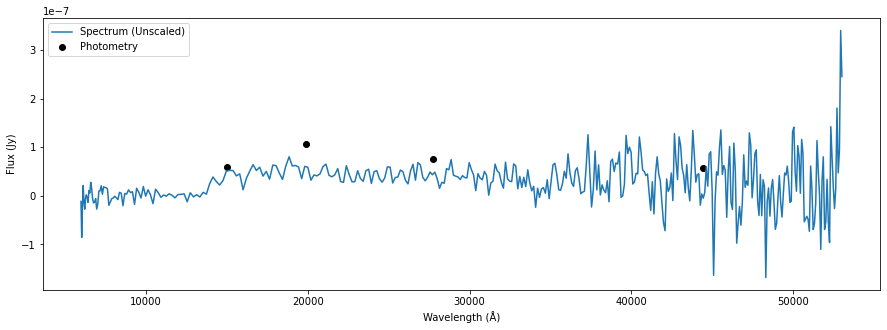

In [55]:
plt.figure(figsize=(15,5))
plt.plot(specs_wl, specs_fl, label='Spectrum (Unscaled)')
plt.scatter(wavelength_photometric, flux_photometric, marker='o', label='Photometry',color='black',zorder=2)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux (Jy)')
plt.legend()
plt.show()

## 5. Import and Generate Necessary Functions Needed for Conversions and Calibration

In [ ]:
path_to = '/Users/alexamia_1/Desktop/CODE/results/filters/JWST/NIRCAM/'
filter_tab150 = ascii.read(path_to+'NIRCAM_F150W.txt')
filter_tab200 = ascii.read(path_to+'NIRCAM_F200W.txt')
filter_tab277 = ascii.read(path_to+'NIRCAM_F277W.txt')
filter_tab444 = ascii.read(path_to+'NIRCAM_F444W.txt')

# Here, the provided JWST NIRCam transmission curves label 'col1' as the wavelengths of the transmission curve, and 'col2' is the transmission itself. 
filt_tab1 = filter_tab150[filter_tab150['col2']>0.0] # Mask regions of the transmission curve > 0
filt_tab2 = filter_tab200[filter_tab200['col2']>0.0]
filt_tab3 = filter_tab277[filter_tab277['col2']>0.0]
filt_tab4 = filter_tab444[filter_tab444['col2']>0.0]

# Upper and lower bounds of the wavelength array needed to calculate the bandpass-averaged flux below
lam_low = np.array([filt_tab1['col1'].min(),filt_tab2['col1'].min(),filt_tab3['col1'].min(),filt_tab4['col1'].min()])
lam_up = np.array([filt_tab1['col1'].max(),filt_tab2['col1'].max(),filt_tab3['col1'].max(),filt_tab4['col1'].max()])

trans_vals = [filt_tab1['col2'].data,filt_tab2['col2'].data,filt_tab3['col2'].data,filt_tab4['col2'].data] # Transmission curve values (nested list)
trans_lams = [filt_tab1['col1'],filt_tab2['col1'],filt_tab3['col1'],filt_tab4['col1']] # Transmission curve wavelengths (nested list)

    
def flamb_to_fnu(spec_flamb, freq): ## Converts fluxes from f_lambda to f_nu
  #spec_flamb in units of erg s-1 cm-2 A-2, wav in A
  c = 3e18
  return spec_flamb*(c/freq**2)   ##erg s-1 cm-2 Hz-1

def lamb_to_nu(w):
  # Wavelength, w in Angstroms
  return 3e18/w

def fnu_to_flamb(spec_fnu, freq): ## Converts fluxes from f_nu to f_lambda
  c = 3e18
  return spec_fnu*(freq**2/c)   ##erg s-1 cm-2 Hz-1


def photometric_flux_fnu(spectrum, transmission, numin, numax):
  '''
  Photometry in f_nu
  Tranmssion curve is T (wavelength values, lambda, in Angstroms)
  '''
  top = integrate.quad(lambda nu: 1/nu*(spectrum(nu)*transmission(3e18/nu)), numin, numax)[0]
  bottom = integrate.quad(lambda nu: 1/nu*transmission(3e18/nu), numin, numax)[0]
  return top/bottom

def avg_bpf(lam, spec, lam_l, lam_u, trans, trans_lam):
  '''
  Function to measure the bandpass-averaged flux directly from a spectrum to compare to its corresponding photometry 
  and filter transmission curves from imaging.
  '''
  avgbpf = [] # List where bandpass fluxes from spectrum will be saved
  mask = np.isfinite(spec) # Mask regions where data exists to avoid issue with nans
  spec_use = spec[mask]
  lam_use = lam[mask]
  
  # Interpolate the transmission curve onto the wavelength grid of the spectrum
  interp_func = interp1d(trans_lam, trans, kind='linear', bounds_error=False, fill_value=0.0)
  trans_interp = interp_func(lam_use)
  
  # Apply the transmission curve to the relevant wavelength range
  mask_band = (lam_use >= lam_l) & (lam_use <= lam_u)
  if not np.any(mask_band):
      return np.nan
  
  lam_band = lam_use[mask_band]
  spec_fl = spec_use[mask_band]
  trans_fl = trans_interp[mask_band]  # Interpolated transmission curve
  
  # Numerator: \int \lambda f_{\lambda}(\lambda) \epsilon(\lambda) d\lambda
  top = lam_band * spec_fl * trans_fl
  
  # Denominator: \int \lambda \epsilon(\lambda) d\lambda
  bottom = lam_band * trans_fl
  
  # Perform the trapezoidal integration
  top_I = np.trapz(top, x=lam_band)
  bottom_I = np.trapz(bottom, x=lam_band)
  
  avg_bpf_vals = top_I / bottom_I
  avgbpf.append(avg_bpf_vals)
  
  # Convert from erg / (s * cm^2 * Angstrom) to Jy
  result_in_erg_per_s_cm2_AA = np.median(avgbpf) * u.erg / (u.s * u.cm**2 * u.AA)
  result_in_jy = (result_in_erg_per_s_cm2_AA * ((lam_band.mean()*u.AA)**2) / (const.c)).to(u.Jy)
  
  return result_in_jy.value

def avg_bpf_err(lam, spec_err, lam_l, lam_u, trans, trans_lam): 
  '''
  Similar function as avg_bpf(), but takes into account error propagation for the spectrum's noise/uncertainties. 
  '''
  avgbpf_err = []
  mask = np.isfinite(spec_err) # Identify the finite values in spec_err
  # Apply the mask to get the finite values only
  spec_err_use = spec_err[mask]
  lam_use = lam[mask]

  # Interpolate the transmission curve onto the wavelength grid of the spectrum
  interp_func = interp1d(trans_lam, trans, kind='linear', bounds_error=False, fill_value=0.0)
  trans_interp = interp_func(lam_use)

  # Apply the transmission curve to the relevant wavelength range
  mask_band = (lam_use >= lam_l) & (lam_use <= lam_u)
  if not np.any(mask_band):
      return np.nan

  lam_band = lam_use[mask_band]
  spec_err_fl = spec_err_use[mask_band]
  trans_fl = trans_interp[mask_band]  # Interpolated transmission curve

  # Numerator: \int \lambda^2 f_{\lambda, err}^2(\lambda) \epsilon^2(\lambda) d\lambda
  top = (lam_band * spec_err_fl * trans_fl) ** 2

  # Denominator: \int \lambda^2 \epsilon^2(\lambda) d\lambda
  bottom = (lam_band * trans_fl) ** 2

  # Perform the trapezoidal integration
  top_I = np.trapz(top, x=lam_band)
  bottom_I = np.trapz(bottom, x=lam_band)

  avg_bpf_err_vals = np.sqrt(top_I / bottom_I)
  avgbpf_err.append(avg_bpf_err_vals)

  # Convert from erg / (s * cm^2 * Angstrom) to Jy
  result_in_erg_per_s_cm2_AA = np.median(avgbpf_err) * u.erg / (u.s * u.cm**2 * u.AA)
  result_in_jy = (result_in_erg_per_s_cm2_AA * ((lam_band.mean()*u.AA)**2) / (const.c)).to(u.Jy)

  return result_in_jy.value



def avg_bpf_arr(lams, specs, spec_errs=None):
  '''
  Generating arrays of the bandpass-averaged fluxes and their uncertainties
  '''
  avg_bpf_vals = []
  avg_bpf_err_vals = []
  
  for i in range(len(lam_low)):
      avg_bpf_vals.append(avg_bpf(lam=lams, spec=specs, lam_l=lam_low[i], lam_u=lam_up[i], trans=trans_vals[i],trans_lam = trans_lams[i]))
      
      if spec_errs is not None:
          avg_bpf_err_vals.append(avg_bpf_err(lam=lams, spec_err=spec_errs, lam_l=lam_low[i], lam_u=lam_up[i], trans=trans_vals[i],trans_lam = trans_lams[i]))
  
  avg_bpf_vals_array = np.array(avg_bpf_vals) # Converting from list to array
  
  if spec_errs is not None:
      avg_bpf_err_vals_array = np.array(avg_bpf_err_vals) # Converting from list to array
      return avg_bpf_vals_array, avg_bpf_err_vals_array
  
  return avg_bpf_vals_array


def interpolate_correction(correction, detection_mask):
  '''
  Function to interpolate correction factors
  '''
  valid_indices = np.where(detection_mask)[0]
  if len(valid_indices) == 0:
      return correction  # No valid indices to interpolate
  invalid_indices = np.where(~detection_mask)[0]
  for idx in invalid_indices:
      closest_valid_idx = valid_indices[np.argmin(np.abs(valid_indices - idx))] # Closest valid index where correction is taken into account
      correction[idx] = correction[closest_valid_idx]
  return correction

## 6. Apply the Scaling Correction


Because calculating the bandpass-averaged flux requires us to be in $F_\lambda$, we need to convert our spectrum and observed photometry in units of $F_\lambda$ before we can reconvert to $F_\nu$. It is, however, up to the user on how they want to interpret their fluxes!

In [ ]:
def correction_curve(table,i):
  # Spectral wavelengths in Angstroms
  lams = table['specs_wave_AA'][i] 

  # Convert spectral flux from Jy to ers/s/cm2/AA
  specs_jy = table['specs_flux_jy'][i] * u.Jy
  specs_erg_per_s_cm2_hz = specs_jy.to(u.erg / (u.s * u.cm**2 * u.Hz))
  specs = (specs_erg_per_s_cm2_hz * const.c / (lams * u.AA)**2).to(u.erg / (u.s * u.cm**2 * u.AA)).value

  # Convert spectral flux errors 
  specs_jy_err = table['specs_fluxerr_jy'][i] * u.Jy
  specs_erg_per_s_cm2_hzerr = specs_jy_err.to(u.erg / (u.s * u.cm**2 * u.Hz))
  spec_err = (specs_erg_per_s_cm2_hzerr * const.c / (lams * u.AA)**2).to(u.erg / (u.s * u.cm**2 * u.AA)).value

  # Get photometric filters and data
  flux_photometric = ([j for j in table['FLUX_F150W', 'FLUX_F200W','FLUX_F277W', 'FLUX_F444W'][i]]*(u.nJy)).to(u.Jy).value
  phots_err = ([j for j in table['FLUXERR_F150W', 'FLUXERR_F200W','FLUXERR_F277W','FLUXERR_F444W'][i]]*(u.nJy)).to(u.Jy).value

  
  
  # Compute synthetic photometry in the same bands
  bpfs, bpfs_errs = avg_bpf_arr(lams=lams, specs=specs, spec_errs=spec_err)

  # Compute signal to noise (S/N) detection cuts and apply detection mask
  signal_to_noise = np.array(bpfs) / np.array(bpfs_errs) # Bandpass-averaged flux S/N ratio
  signal_to_noise2 = np.array(flux_photometric) / np.array(phots_err) # Observed flux S/N ratio
  valid_indices = (signal_to_noise >= 2) & (signal_to_noise2 >=2) 
  
  # Mask what photometry and BPF satisfies this criteria
  wavelength_valid = wavelength_photometric[valid_indices]
  flux_valid = flux_photometric[valid_indices]
  bpfs_valid = bpfs[valid_indices]
  phots_err_valid = phots_err[valid_indices]
  bpfs_err_valid = bpfs_errs[valid_indices]


      
# Compute correction factors where there is detection
# Wherever there is a valid index, take the ratio of the observed flux to BPF, otherwise make it nan
  correction = np.where(valid_indices, flux_photometric / bpfs, np.nan) 
# Interpolate missing correction factors
  correction = interpolate_correction(correction, valid_indices)


# Fit a Chebyshev polynomial to valid correction factors
  valid_center = wavelength_photometric[~np.isnan(correction)]
  valid_correction = correction[~np.isnan(correction)]

  num_filters = np.sum(valid_indices)
  
  correction_applied = num_filters > 2 # if more than two filters are selected, continue and apply correction
  
  # Evaluate polynomial fit over full spectral range
  flux_spectral = table['specs_flux_jy'][i] # Call back original spectral flux in units of Jy to compare to photometry [Jy]
  flux_spectral_err = table['specs_fluxerr_jy'][i]
  wavelength_spectral = lams

## We define a Chebyshev polynomial and its degree
  if correction_applied:
      degree = min(num_filters - 1, 3)

    # Step 1: Calculating the weight of each valid ratio so that the fit is weighted accurately
      sigma_ratio = np.sqrt(
          (phots_err_valid / flux_valid)**2 + (bpfs_err_valid / bpfs_valid)**2
      ) * (flux_valid / bpfs_valid)

      sigma_ratio = np.abs(np.clip(sigma_ratio, 1e-8, np.inf))
      valid_mask = np.isfinite(sigma_ratio)

      weights = 1.0 / sigma_ratio[valid_mask]
      valid_x = wavelength_valid[valid_mask]
      valid_y = (flux_valid / bpfs_valid)[valid_mask]

      chebyshev_fit = Chebyshev.fit(valid_x, valid_y, deg=degree, w=weights)

      poly_fit_spectral = chebyshev_fit(wavelength_spectral) # Apply function to the spectrum's wavelength array

      poly_fit_phot = chebyshev_fit(wavelength_photometric) # Apply function to the photometry's wavelength array
      

      # Step 2: Define left and right edge values based on fit at edges
      left_val = chebyshev_fit(valid_x[0])
      right_val = chebyshev_fit(valid_x[-1])

      # Step 3: Manually evaluate correction across the full grid with clamping 
      # such that the curve is not extrapolated past the valid filters and instead adopts the left/right-most correction factor
      correction = np.piecewise(
          wavelength_spectral,
          [
              wavelength_spectral < valid_x[0],             # Left-hand side
              wavelength_spectral > valid_x[-1],            # Right-hand side
              (wavelength_spectral >= valid_x[0]) & (wavelength_spectral <= valid_x[-1])  # Valid fit range
          ],
          [
              left_val,
              right_val,
              chebyshev_fit
          ]
      )
      # Step 4: Smooth the correction curve if needed. Box1DKernel is a smoothing filter.
      smoothed_correction = convolve(correction, Box1DKernel(width=10), boundary='extend')
    
      # Step 5: Apply smoothed correction to spectrum
      flux_corrected = flux_spectral * smoothed_correction 
      flux_err_corrected = flux_spectral_err * smoothed_correction

  else:
    # If num_filters is not satisfied, do not apply any correction
      flux_corrected = flux_spectral
      flux_err_corrected = flux_spectral_err
  
  # Convert spectral flux from f_nu [Jy] to f_lambda [erg/s/cm2/AA]
  specs_jy_corr = flux_corrected * u.Jy
  specs_erg_per_s_cm2_hz_corr = specs_jy_corr.to(u.erg / (u.s * u.cm**2 * u.Hz))
  specs_corr = (specs_erg_per_s_cm2_hz_corr * const.c / (wavelength_spectral * u.AA)**2).to(u.erg / (u.s * u.cm**2 * u.AA)).value

  # Convert errors
  specs_jy_err_corr = flux_err_corrected * u.Jy
  specs_erg_per_s_cm2_hzerr_corr = specs_jy_err_corr.to(u.erg / (u.s * u.cm**2 * u.Hz))
  spec_err_corr = (specs_erg_per_s_cm2_hzerr_corr * const.c / (wavelength_spectral * u.AA)**2).to(u.erg / (u.s * u.cm**2 * u.AA)).value

  # Bandpass-averaged flux array
  bpfs_corr, bpfs_errs_corr = avg_bpf_arr(lams=wavelength_spectral, specs=specs_corr, spec_errs=spec_err_corr)

  
  
  # Convert corrected fnu (Jy) to erg/s/cm^2/Hz
  flux_corr_nuhz = (flux_corrected * u.Jy).to(u.erg / (u.s * u.cm**2 * u.Hz)).value
  freqs_spectral = lamb_to_nu(wavelength_spectral)

  # Convert to F_lambda
  flux_corr_flam = fnu_to_flamb(flux_corr_nuhz, freqs_spectral)

  
  # Convert errors to F_lambda
  flux_err_corr_nuhz = (flux_err_corrected * u.Jy).to(u.erg / (u.s * u.cm**2 * u.Hz)).value
  flux_err_corr_flam = fnu_to_flamb(flux_err_corr_nuhz, freqs_spectral)
  
  
  flux_phot_nuhz = (flux_photometric * u.Jy).to(u.erg / (u.s * u.cm**2 * u.Hz)).value
  phots_err_nuhz = (phots_err * u.Jy).to(u.erg / (u.s * u.cm**2 * u.Hz)).value
  freqs_phot = lamb_to_nu(wavelength_photometric)

  flux_phot_flam = fnu_to_flamb(flux_phot_nuhz, freqs_phot)
  phots_err_flam = fnu_to_flamb(phots_err_nuhz, freqs_phot)
  
  %matplotlib inline

  if correction_applied:
      fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(20, 10), facecolor='white', sharex=True)
  else:
      fig, ax2 = plt.subplots(figsize=(20, 5), facecolor='white')


  # --- Correction Subplot ---
  if correction_applied:
      ax1.plot(wavelength_spectral, smoothed_correction, color='black')

      ax1.set_ylabel(r'Correction Factor', fontsize=20)
      ax1.set_title('Spectral Correction Curve', fontsize=18)
      ax1.tick_params(axis='both', labelsize=16)
      ax1.grid(alpha=0.3)

  # --- Main Spectrum Plot ---
  # Plot the corrected and uncorrected spectrum
  ax2.step(wavelength_spectral, flux_corr_flam, where='mid', color='black', lw=2, label='Corrected Spectrum')
  ax2.step(wavelength_spectral, specs, where='mid', color='red', alpha=0.5, lw=1, label='Original Spectrum')
  # Plot the uncertainties/noise on the spectrum
  ax2.errorbar(wavelength_spectral, flux_corr_flam, yerr=np.abs(flux_err_corr_flam), color='black', alpha=0.8, lw=0.5)

  # Plot the photometry 
  ax2.scatter(wavelength_photometric, flux_phot_flam, color='#ff499e', label='Photometric Flam', s=70)
  ax2.errorbar(wavelength_photometric, flux_phot_flam, yerr=phots_err_flam, fmt='o', color='#ff499e', capsize=3)

  if correction_applied:
      # Highlight only the used filters in the fit
      used_filters = wavelength_valid[valid_mask]
      used_fluxes = fnu_to_flamb((flux_valid[valid_mask]*u.Jy).to(u.erg/(u.s*u.cm**2*u.Hz)).value,
                                  lamb_to_nu(used_filters))
      ax2.scatter(used_filters, used_fluxes, color='green', s=100, marker='s', label='Used in Fit')

  ax2.set_xlabel(r'Wavelength [$\AA$]', fontsize=20)
  ax2.set_ylabel(r'Flux Density, $f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=20)
  ax2.legend(fontsize=14)
  ymax = 1.5*np.nanmax(flux_corr_flam[20:])
  ymin = np.nanmin(flux_corr_flam[20:])/2
  ax2.set_ylim(ymin, ymax)
  ax2.tick_params(axis='both', labelsize=16)
  ax2.grid(alpha=0.3)
  plt.tight_layout()



  return wavelength_spectral, flux_corrected, flux_err_corrected, smoothed_correction # Flux + errors in units of Jy, wavelengths in units of Angstroms



## 7. Validate the Calibration

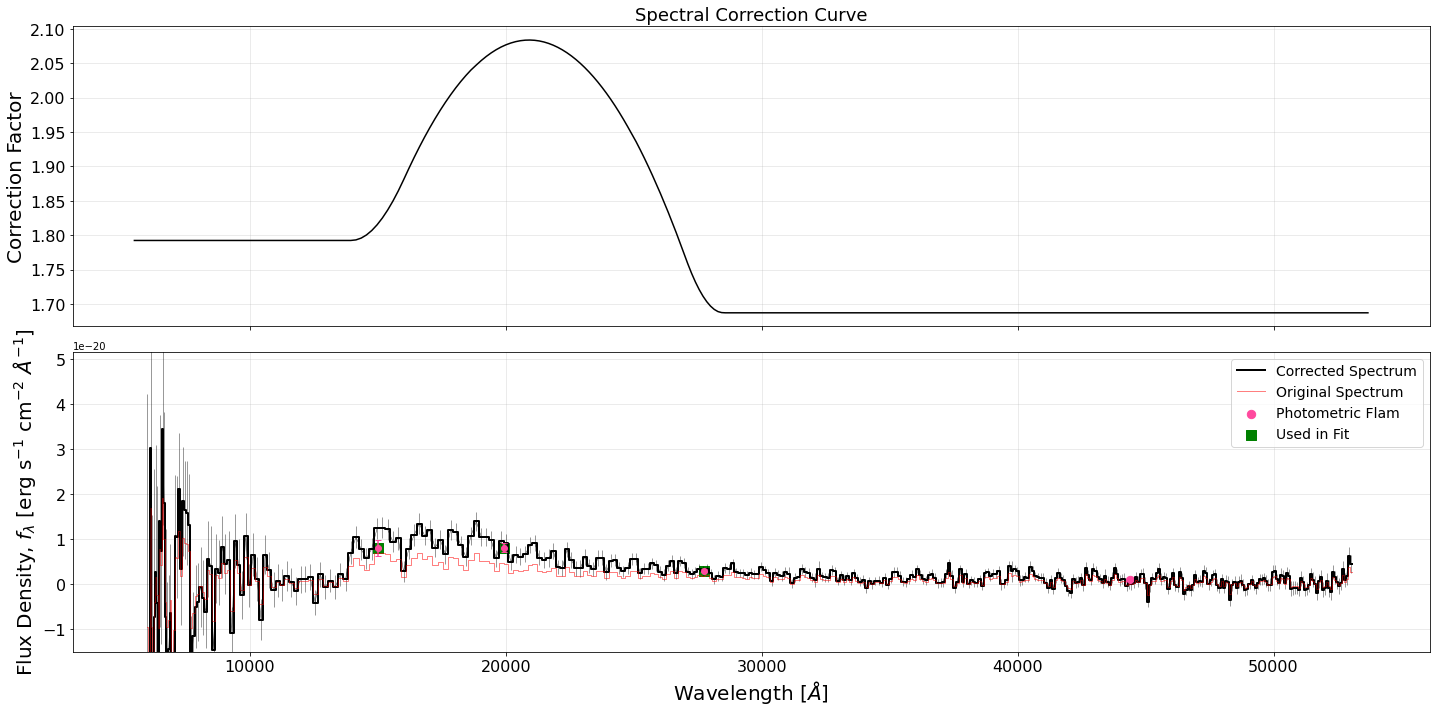

In [67]:
wave_spec_final, flux_spec_final, flux_err_spec_final, smoothed_corr = correction_curve(table = final_table, i = 0)